Load in data

In [6]:
# imports

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import time

# use the widget backend for interactive plots inside the notebook
# make sure `ipympl` is installed and the kernel has been restarted
%matplotlib widget

# TRY NORMALIZING DATA
# StandardScalarx

In [2]:

proper = pd.read_csv('proper_asteroid_data_small.csv')
families = pd.read_csv('family_membership.csv')

df = proper.merge(families[['name','family1']], on='name', how='left')
df['family1'] = df['family1'].fillna(0).astype(int)

family_names = {
    4:    'Vesta',
    15:   'Eunomia',
    20:   'Massalia',
    24:   'Themis',
    158:  'Koronis',
    170:  'Maria',
    221:  'Eos',
    490:  'Veritas',
    847:  'Agnia',
    1040: 'Natasha',
}
feature_columns = ['a', 'e', 'sin_i']
X = df[feature_columns].dropna().values
len(df)

/tmp/ipykernel_40518/3460491855.py:2: DtypeWarning: Columns (0: name, 1: near1) have mixed types. Specify dtype option on import or set low_memory=False.
  families = pd.read_csv('family_membership.csv')


103557

Look for most common asteroid families
Eos
Eunomia?
Flora
Hungaria
Hygiea
Koronis
Nysa
Themis
Vesta


In [3]:
def plot_family(family_id):
    name = family_names.get(family_id, f'Family {family_id}')
    members = df[df['family1'] == family_id]
    background = df[df['family1'] != family_id]
    print(f"{name} members in dataset: {len(members)}")
    a_min, a_max = members['a'].min() - 0.3, members['a'].max() + 0.3

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plots = [('a','e'), ('a','sin_i'), ('e','sin_i')]

    for ax, (xcol, ycol) in zip(axes, plots):
        ax.scatter(background[xcol], background[ycol], s=1, c='lightgray', alpha=0.3, label='background')
        ax.scatter(members[xcol], members[ycol], s=8, c='red', alpha=0.7, label=f'{name} (n={len(members)})')
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title(f'{name} — {xcol} vs {ycol}')
        ax.legend()
        # Zoom in based on members' data
        x_min = members[xcol].min() - 0.1
        x_max = members[xcol].max() + 0.1
        y_min = members[ycol].min() - 0.1
        y_max = members[ycol].max() + 0.1
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.savefig(f'{name.lower()}_family.png', dpi=150)
    plt.show()

Vesta members in dataset: 3410


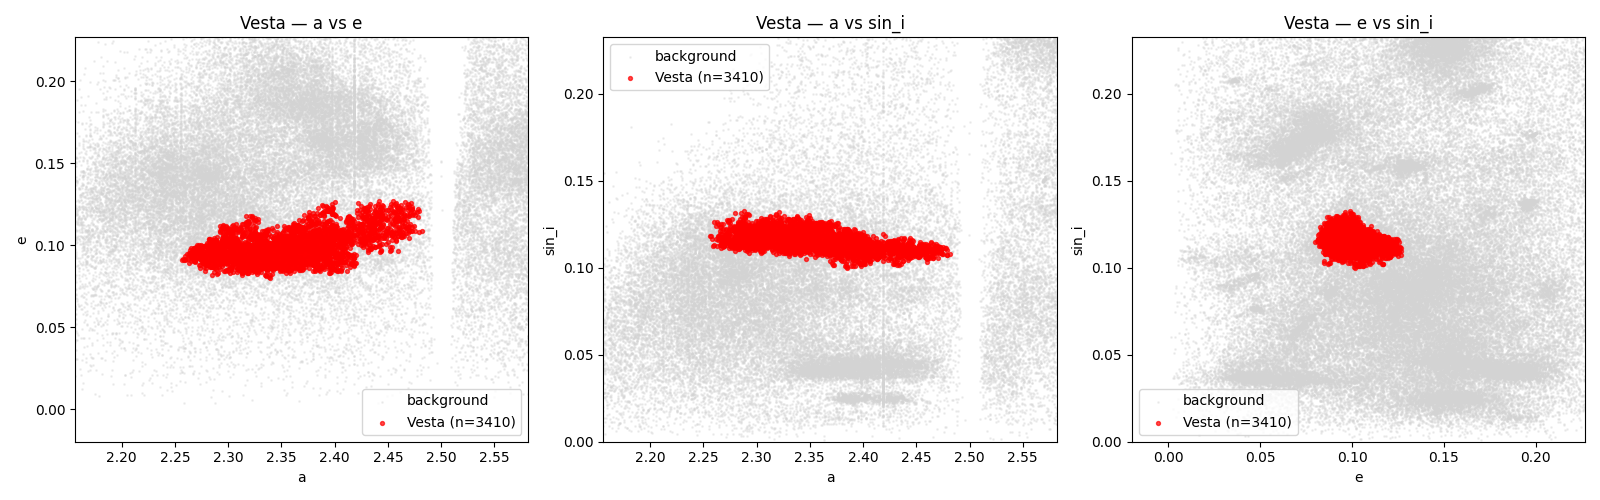

In [4]:
plot_family(4)


Eos members in dataset: 4518


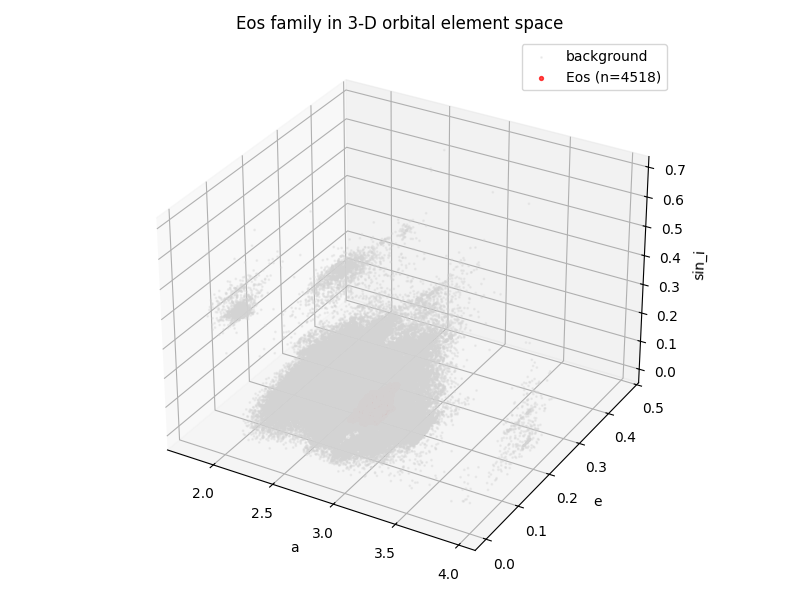

In [7]:
from mpl_toolkits.mplot3d import Axes3D    # noqa: F401 – needed for the 3‑D backend

def plot_family_3d(family_id):
    name = family_names.get(family_id, f'Family {family_id}')
    members    = df[df['family1'] == family_id]
    background = df[df['family1'] != family_id]

    print(f"{name} members in dataset: {len(members)}")

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    ax.scatter(background['a'], background['e'], background['sin_i'],
               s=1, c='lightgray', alpha=0.3, label='background')
    ax.scatter(members['a'], members['e'], members['sin_i'],
               s=8, c='red', alpha=0.7, label=f'{name} (n={len(members)})')

    ax.set_xlabel('a')
    ax.set_ylabel('e')
    ax.set_zlabel('sin_i')
    ax.set_title(f'{name} family in 3‑D orbital element space')
    ax.legend()
    plt.tight_layout()
    plt.show()

# call it for Vesta (family 4)
plot_family_3d(221)

In [15]:
# plot_family(490)

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
k1, k2, k3 = 5/4, 2, 2 # paper section 2
zone_boundaries = [(0.0, 2.065), (2.065, 2.3), (2.3, 2.501), (2.501, 2.825), (2.825, 2.958), (2.959, 3.030), (3.278, 4)] # dont know where it ends
zone_cutoff = (0, 120, 140, 160, 160, 120, 160, 0) # 1 and 8 dont have a boundary
def delta_v(u,v):
    """
    Velocity-space distance metric from Equation 2
    u, v: arrays containing 'a', 'e', 'sin_i'
    returns change in velocity between two asteroid
    """
    a0  = (u[0] + v[0]) / 2.0
    n0  = 2.0 * np.pi / (a0 ** 1.5)  # rad/yr
    da  = u[0] - v[0]
    de  = u[1] - v[1]
    dsin_i = u[2] - v[2]

    dv_AU_yr = n0 * a0 * np.sqrt(k1 * (da / a0)**2 + k2* (de)**2 + k3* (dsin_i)**2
    )
    return dv_AU_yr * 4740.9  # convert to m/s

# def hcm(df, zone, min_members=5):

In [17]:
def plot_family_vs_hcm(family_id, d_cutoff=60):
    name = family_names.get(family_id, f'Family {family_id}')

    # Ground truth members
    members = df[df['family1'] == family_id]

    # Find seed and run HCM
    seed_idx = df[df['name'] == family_id].index[0]
    hcm_indices = hcm(X, seed_idx, d_cutoff=d_cutoff)
    hcm_mask = np.array(list(hcm_indices))
    hcm_members = df.iloc[hcm_mask]

    print(f"{name} — AstDys: {len(members)}, HCM: {len(hcm_indices)}")

    plots = [('a', 'e'), ('a', 'sin_i'), ('e', 'sin_i')]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    for col, (xcol, ycol) in enumerate(plots):
        x_min = members[xcol].min() - 0.1
        x_max = members[xcol].max() + 0.1
        y_min = members[ycol].min() - 0.1
        y_max = members[ycol].max() + 0.1

        # Top row — ground truth
        ax = axes[0, col]
        ax.scatter(df[xcol], df[ycol], s=1, c='lightgray', alpha=0.3, label='background')
        ax.scatter(members[xcol], members[ycol], s=8, c='red', alpha=0.7,
                   label=f'AstDys (n={len(members)})')
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        ax.set_title(f'{name} Ground Truth — {xcol} vs {ycol}')
        ax.legend()

        # Bottom row — HCM result
        ax = axes[1, col]
        ax.scatter(df[xcol], df[ycol], s=1, c='lightgray', alpha=0.3, label='background')
        ax.scatter(hcm_members[xcol], hcm_members[ycol], s=8, c='blue', alpha=0.7,
                   label=f'HCM (n={len(hcm_indices)})')
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        ax.set_title(f'{name} HCM (cutoff={d_cutoff} m/s) — {xcol} vs {ycol}')
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'{name.lower()}_hcm_vs_truth.png', dpi=150)
    plt.show()

# Usage
# plot_family_vs_hcm(4)   # Vesta

In [ ]:
vesta_region = df[(df['a'] > 2.1) & (df['a'] < 2.6)].copy().reset_index(drop=True)
X_small = vesta_region[['a', 'e', 'sin_i']].values

print(f"Vesta region size: {len(X_small)}")  # should be ~50-100k, much more manageable

vesta_idx_small = vesta_region[vesta_region['name'] == 4].index[0]
fam = hcm(X_small, vesta_idx_small, d_cutoff=60)
print(f"Family size: {len(fam)}")

Vesta region size: 51051
  iter   1 | frontier=  154 | family=   155 | remaining=  50896 | 0.0s elapsed
  iter   2 | frontier=  731 | family=   886 | remaining=  50165 | 0.6s elapsed
  iter   3 | frontier= 1339 | family=  2225 | remaining=  48826 | 3.4s elapsed
  iter   4 | frontier= 1359 | family=  3584 | remaining=  47467 | 8.6s elapsed
  iter   5 | frontier= 1291 | family=  4875 | remaining=  46176 | 13.7s elapsed
  iter   6 | frontier= 1176 | family=  6051 | remaining=  45000 | 18.6s elapsed
  iter   7 | frontier= 1127 | family=  7178 | remaining=  43873 | 22.9s elapsed
  iter   8 | frontier= 1064 | family=  8242 | remaining=  42809 | 27.1s elapsed
  iter   9 | frontier= 1004 | family=  9246 | remaining=  41805 | 30.9s elapsed
  iter  10 | frontier= 1102 | family= 10348 | remaining=  40703 | 34.6s elapsed
  iter  11 | frontier= 1318 | family= 11666 | remaining=  39385 | 38.6s elapsed
  iter  12 | frontier= 1439 | family= 13105 | remaining=  37946 | 43.3s elapsed
  iter  13 | fronti

In [22]:
# Check ground truth count in your regional subset
vesta_true = vesta_region[vesta_region['family1'] == 4]
print(f"AstDys Vesta members in this region: {len(vesta_true)}")
print(f"Total asteroids in region: {len(vesta_region)}")

for cutoff in [30, 40, 50, 60]:
    t = time.time()
    result = hcm(X, vesta_idx_small, d_cutoff=cutoff)
    print(f"cutoff={cutoff:3d} m/s -> HCM={len(result):6d} | "
          f"AstDys={len(vesta_true):6d} | "
          f"ratio={len(result)/max(len(vesta_true),1):.2f} | "
          f"{time.time()-t:.1f}s")

AstDys Vesta members in this region: 3410
Total asteroids in region: 51051
  iter   1 | frontier=    1 | family=     2 | remaining= 103555 | 0.0s elapsed
  iter   2 | frontier=    1 | family=     3 | remaining= 103554 | 0.0s elapsed
  iter   3 | frontier=    4 | family=     7 | remaining= 103550 | 0.0s elapsed
  iter   4 | frontier=   12 | family=    19 | remaining= 103538 | 0.1s elapsed
  iter   5 | frontier=   14 | family=    33 | remaining= 103524 | 0.1s elapsed
  iter   6 | frontier=   27 | family=    60 | remaining= 103497 | 0.2s elapsed
  iter   7 | frontier=   74 | family=   134 | remaining= 103423 | 0.4s elapsed
  iter   8 | frontier=  118 | family=   252 | remaining= 103305 | 1.0s elapsed
  iter   9 | frontier=  160 | family=   412 | remaining= 103145 | 1.8s elapsed
  iter  10 | frontier=  186 | family=   598 | remaining= 102959 | 3.0s elapsed
  iter  11 | frontier=  147 | family=   745 | remaining= 102812 | 4.3s elapsed
  iter  12 | frontier=   89 | family=   834 | remaining=

In [26]:
print(f"X shape: {X.shape}")
print(f"X_test shape: {X_small.shape}")
print(f"vesta_region shape: {vesta_region.shape}")
print(f"AstDys Vesta members in vesta_region: {len(vesta_true)}")
print(f"vesta_idx_small: {vesta_idx_small}")

X shape: (103557, 3)
X_test shape: (51051, 3)
vesta_region shape: (51051, 11)
AstDys Vesta members in vesta_region: 3410
vesta_idx_small: 0


In [27]:
result = hcm(X_small, vesta_idx_small, d_cutoff=42)

for cutoff in [41, 42, 43, 44, 45, 46, 47, 48, 49]:
    result = hcm(X_small, vesta_idx_small, d_cutoff=cutoff)
    print(f"cutoff={cutoff} -> HCM={len(result)} | AstDys=3410 | ratio={len(result)/3410:.2f}")

  iter   1 | frontier=   55 | family=    56 | remaining=  50995 | 0.0s elapsed
  iter   2 | frontier=  238 | family=   294 | remaining=  50757 | 0.2s elapsed
  iter   3 | frontier=  566 | family=   860 | remaining=  50191 | 1.1s elapsed
  iter   4 | frontier=  818 | family=  1678 | remaining=  49373 | 3.2s elapsed
  iter   5 | frontier=  884 | family=  2562 | remaining=  48489 | 6.2s elapsed
  iter   6 | frontier=  846 | family=  3408 | remaining=  47643 | 9.4s elapsed
  iter   7 | frontier=  840 | family=  4248 | remaining=  46803 | 12.5s elapsed
  iter   8 | frontier=  731 | family=  4979 | remaining=  46072 | 15.6s elapsed
  iter   9 | frontier=  677 | family=  5656 | remaining=  45395 | 18.3s elapsed
  iter  10 | frontier=  673 | family=  6329 | remaining=  44722 | 20.8s elapsed
  iter  11 | frontier=  491 | family=  6820 | remaining=  44231 | 23.2s elapsed
  iter  12 | frontier=  473 | family=  7293 | remaining=  43758 | 25.0s elapsed
  iter  13 | frontier=  419 | family=  7712 | 

In [30]:
# What families are in the vesta_region?
family_counts = vesta_region[vesta_region['family1'] > 0]['family1'].value_counts()
print("Families in vesta_region:")
print(family_counts.head(15))

# Plot the region colored by family
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

# background
bg = vesta_region[vesta_region['family1'] == 0]
ax.scatter(bg['a'], bg['e'], s=1, c='lightgray', alpha=0.2)

# top 5 families in region, each a different color
colors = ['red','blue','green','orange','purple']
for (fid, count), color in zip(family_counts.head(5).items(), colors):
    fam = vesta_region[vesta_region['family1'] == fid]
    name = family_names.get(fid, str(fid))
    ax.scatter(fam['a'], fam['e'], s=4, c=color, 
               alpha=0.7, label=f'{name} (n={count})')

ax.set_xlabel('a (AU)'); ax.set_ylabel('e')
ax.legend(); ax.set_title('All families in Vesta region')
plt.tight_layout()
plt.savefig('vesta_region_families.png', dpi=150)
plt.show()

Families in vesta_region:
family1
135     3972
4       3410
15      1306
20       868
170      509
25       414
2076     399
163      195
1658     189
480       85
298       70
883       68
752       56
1338      51
194       43
Name: count, dtype: int64


/tmp/ipykernel_619959/1544471814.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [31]:
AU_m = 1.496e11        # meters per AU
yr_s = 365.25*24*3600  # seconds per year
print(f"1 AU/yr = {AU_m/yr_s:.2f} m/s")  # ~4740 m/s

1 AU/yr = 4740.54 m/s
